# Forecasting daily settled TPV with an LSTM

A virtual card program settles millions of dollars of merchant payments every business day. Treasury needs tomorrow's settled TPV (total payment volume) to size funding lines; settlement operations staffs against it; finance paces the month against plan. Today that number comes from same-weekday-last-week style pacing heuristics. This notebook builds an LSTM (long short-term memory network) forecaster the way Jason Brownlee's *Long Short-Term Memory Networks With Python* teaches, and then answers the question that actually matters: does it beat the heuristics, and does it beat an honest linear baseline given the identical inputs?

The answer up front, because it shapes how to read everything below: the sequence models cut the desk heuristic's error by roughly two thirds, which is the business win. Between the two model candidates, the linear baseline and the LSTM finish in a statistical tie on this series, so the recommendation is to ship the cheaper model and keep the LSTM harness, with explicit criteria for when depth starts paying. A deep model losing gracefully to a well-built baseline is not a failed project; it is what honest evaluation looks like, and the book says as much.

What the notebook does:

1. **Background, written to be repeated in a business review**: what a sequence model is, what the three LSTM gates do, and why settlement series (lags, month-end crunches, weekday funding patterns) are the natural habitat.
2. **Frames forecasting as supervised learning**: a 28-business-day sliding window over scaled features, the 3D tensor Keras expects, and a leakage-safe chronological split.
3. **Builds the honesty gate first**: persistence, seasonal naive, moving average, and a linear regression on the identical window.
4. **Runs the full book lifecycle**: define, compile, fit, evaluate, predict; loss-curve diagnostics; vanilla vs stacked; a 10-seed stability study with an ensemble, because neural networks are stochastic and one lucky run is not evidence.
5. **Tests claims instead of asserting them**: a feature ablation for the void-rate input, a model-update experiment for refit cadence, and error breakdowns a settlement desk would ask for.

Method follows the book directly: gate-level architecture (ch. 1-2), data preparation (ch. 3), the Keras lifecycle (ch. 4), vanilla and stacked models (ch. 6-7), diagnosing and repeated evaluation (ch. 12), making predictions (ch. 13), updating models (ch. 14).

The dataset is synthetic and deterministic: `data/generate_dataset.py` documents every pattern the models are supposed to find, including load-dependent settlement lag and an operational incident. Same program universe as the [merchant retention](../merchant_retention/) and [virtual card CLV](../virtual_card_clv/) case studies, at the daily operational grain.

## 1. Background: why a sequence model, in plain terms

**The series has memory.** What settles today is mostly what was issued net of voids over the last few business days, shaped by a weekday funding pattern, a month-end crunch of AP (accounts payable) runs, holidays, and program growth. On heavy days the settlement queue itself slows down, pushing volume further out: the lag structure depends on load. A regular regression model sees a table of independent rows; a recurrent network reads the rows in order and carries state from one day to the next, the way a person watching the dashboard does.

**What an LSTM is.** A recurrent network whose unit is a memory cell: an internal state carried across time steps, plus three learned gates that govern it. In the book's terms: the **forget gate** decides what to discard from the cell state, the **input gate** decides which new values update it, and the **output gate** decides what the cell exposes for the current prediction. This gated design (the book's "constant error carousel") is what lets gradients survive long sequences; plain RNNs (recurrent neural networks) fail on long lags because gradients vanish or explode as the network unrolls through time during backpropagation.

**The same three gates, in payment terms** (an analogy, not the mechanics): the cell state is the model's running belief about the program's level and rhythm. The forget gate lets it drop an incident's distortion once the incident ends. The input gate lets it absorb a permanent campaign step-up quickly. The output gate decides how much of that memory today's forecast should use, more of the month-end memory on the 31st than on the 12th.

**Why not just features in a linear model?** That is not a rhetorical question here; it is the experiment. The linear baseline below receives the identical 28-day window. If the LSTM cannot beat it, the honest conclusion is that this series' structure is close enough to linear, and that conclusion ships. The comparison, not enthusiasm for the architecture, is the deliverable.

In [1]:
%matplotlib inline
import os
os.environ['KERAS_BACKEND'] = 'jax'   # Keras 3 is backend-agnostic; JAX is the lightest install
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings('ignore')

ACCENT, SECONDARY, RULE, MUTED, PAPER = '#B4441E', '#8A7B63', '#D8CDBA', '#B9AC96', '#FDF8F0'
plt.rcParams.update({
    'figure.dpi': 88, 'savefig.dpi': 100, 'figure.figsize': (10.9, 3.7),
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': RULE, 'axes.grid': True, 'grid.color': RULE, 'grid.alpha': 0.45,
    'font.size': 10, 'axes.titlesize': 11, 'axes.titleweight': 'bold',
})
IMG = Path('images'); IMG.mkdir(exist_ok=True)
M = mticker.StrMethodFormatter('${x:,.1f}M')

# Fitted-model outputs are cached to artifacts/ (gitignored). Training the whole
# notebook from scratch takes about a minute on a laptop CPU; the cache only
# spares that minute on repeated runs. Delete artifacts/ to retrain everything.
ART = Path('artifacts'); ART.mkdir(exist_ok=True)
def cached(name, fn):
    f = ART / f'{name}.npz'
    if f.exists():
        d = np.load(f)
        return [d[k] for k in d.files]
    out = fn()
    np.savez(f, *out)
    return out

import keras
from keras import layers
keras.utils.set_random_seed(42)

df = pd.read_csv('data/daily_payments.csv', parse_dates=['date'])
df['void_rate'] = df.voided_volume / df.issued_volume
print(f'Keras {keras.__version__} ({keras.backend.backend()} backend) | {len(df)} days '
      f'{df.date.min():%Y-%m-%d}..{df.date.max():%Y-%m-%d} | '
      f'settled TPV ${df.settled_volume.sum()/1e9:,.2f}B')
df.head()

Keras 3.12.3 (jax backend) | 1096 days 2023-01-01..2025-12-31 | settled TPV $2.62B


,date,issued_payments,issued_volume,voided_payments,voided_volume,settled_payments,settled_volume,void_rate
0,2023-01-01,116,119569.33,4,4337.75,0,0.00,0.036278
1,2023-01-02,133,150153.24,4,4651.48,0,0.00,0.030978
2,2023-01-03,3656,4459968.94,136,165506.74,140,152597.09,0.037109
3,2023-01-04,2275,2721780.04,76,90348.02,1410,1746946.62,0.033194
4,2023-01-05,1421,1510397.12,44,46287.55,2501,3019913.10,0.030646


## 2. The series, before any modeling

Look first, model second. Three panels: the issued-to-settled lifecycle at full length, one representative month up close, and the disruption the model will have to live through (the March 2025 duplicate-issuance incident, a void-rate spike that decays over two weeks).

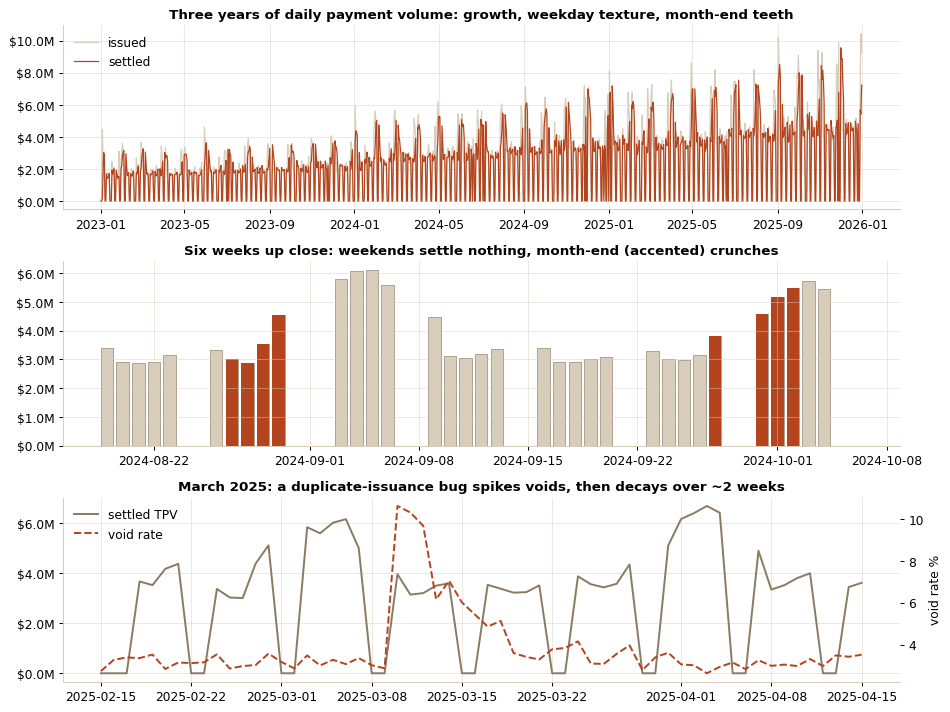

The incident voided $2.5M across two weeks. Whether the model needs the void rate as an explicit input, or the damage already shows through issuance and settlement, is tested in section 8 rather than assumed.


In [2]:
fig, axes = plt.subplots(3, 1, figsize=(10.9, 8.2))
axes[0].plot(df.date, df.issued_volume / 1e6, color=RULE, lw=1.0, label='issued')
axes[0].plot(df.date, df.settled_volume / 1e6, color=ACCENT, lw=1.0, label='settled')
axes[0].set_title('Three years of daily payment volume: growth, weekday texture, month-end teeth')
axes[0].yaxis.set_major_formatter(M); axes[0].legend(frameon=False, loc='upper left')

zoom = df[(df.date >= '2024-08-19') & (df.date <= '2024-10-06')]
axes[1].bar(zoom.date, zoom.settled_volume / 1e6, color=RULE, edgecolor=SECONDARY, lw=0.5)
me = zoom[(zoom.date.dt.day >= 27) | (zoom.date.dt.day <= 2)]
axes[1].bar(me.date, me.settled_volume / 1e6, color=ACCENT)
axes[1].set_title('Six weeks up close: weekends settle nothing, month-end (accented) crunches')
axes[1].yaxis.set_major_formatter(M)

inc = df[(df.date >= '2025-02-15') & (df.date <= '2025-04-15')]
axes[2].plot(inc.date, inc.settled_volume / 1e6, color=SECONDARY, lw=1.6, label='settled TPV')
ax2 = axes[2].twinx()
ax2.plot(inc.date, inc.void_rate * 100, color=ACCENT, lw=1.6, ls='--', label='void rate')
ax2.set_ylabel('void rate %'); ax2.grid(False); ax2.spines['top'].set_visible(False)
axes[2].set_title('March 2025: a duplicate-issuance bug spikes voids, then decays over ~2 weeks')
axes[2].yaxis.set_major_formatter(M)
h1, l1 = axes[2].get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
axes[2].legend(h1 + h2, l1 + l2, frameon=False, loc='upper left')
fig.tight_layout(); fig.savefig(IMG / 'series-overview.png', dpi=100, bbox_inches='tight'); plt.show()

lost = df[(df.date >= '2025-03-10') & (df.date <= '2025-03-24')].voided_volume.sum()
print(f'The incident voided ${lost/1e6:,.1f}M across two weeks. Whether the model needs the void rate '
      'as an explicit input, or the damage already shows through issuance and settlement, is tested '
      'in section 8 rather than assumed.')

Settlement happens on business days only, so the model works on the business-day series: forecasting a Saturday zero is not skill. Weekday structure and the settlement lag are what the window has to carry.

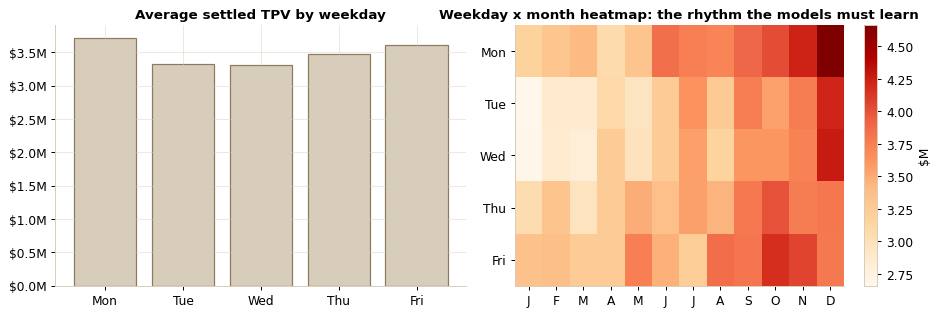

753 business days of 1096 calendar days carry all settlement.


In [3]:
bd = df[df.settled_volume > 0].reset_index(drop=True).copy()
bd['dow'] = bd.date.dt.dayofweek
bd['month_end'] = ((bd.date.dt.day >= 27) | (bd.date.dt.day <= 2)).astype(float)

fig, axes = plt.subplots(1, 2, figsize=(10.9, 3.7))
prof = bd.groupby('dow').settled_volume.mean() / 1e6
axes[0].bar(['Mon', 'Tue', 'Wed', 'Thu', 'Fri'], prof.values, color=RULE, edgecolor=SECONDARY)
axes[0].set_title('Average settled TPV by weekday'); axes[0].yaxis.set_major_formatter(M)
piv = bd.assign(m=bd.date.dt.month).pivot_table(values='settled_volume', index='dow',
                                                columns='m', aggfunc='mean') / 1e6
im = axes[1].imshow(piv.values, aspect='auto', cmap='OrRd')
axes[1].set_yticks(range(5), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri'])
axes[1].set_xticks(range(12), ['J','F','M','A','M','J','J','A','S','O','N','D'])
axes[1].set_title('Weekday x month heatmap: the rhythm the models must learn'); axes[1].grid(False)
fig.colorbar(im, ax=axes[1], label='$M')
fig.tight_layout(); plt.show()
print(f'{len(bd)} business days of {len(df)} calendar days carry all settlement.')

## 3. Framing the sequence as supervised learning

The book's chapter 3 recipe, applied:

1. **Window**: each training example is the last 28 business days of features; the label is the next day's settled TPV. Sliding the window along the series turns one sequence into hundreds of (input, output) pairs: sequence prediction becomes ordinary supervised learning.
2. **Scale**: LSTMs use sigmoid and tanh internally, so inputs are scaled to [0, 1]. The scaler is fit on training rows only; fitting it on all data would leak 2025's growth back into 2023's model.
3. **Shape**: Keras wants a 3D tensor, `[samples, timesteps, features]`. Getting this shape wrong is the most common LSTM error the book warns about, so the shapes are printed, not assumed.
4. **Split by time, never randomly**: train on 2023-01 through 2024-09, validate on 2024-10 through 2024-12 (for loss curves and early stopping), test on all of 2025. A random split would let the model peek at the future.

Features per day, and the case for each slot: settled TPV (the autoregressive core), issued volume (a leading indicator, because of the 1-3 business-day settlement lag), void rate (candidate incident signal, tested later), day-of-week as sine/cosine (so Friday and Monday sit near each other on the weekly circle), a month-end-window flag, and a post-holiday-gap flag. Whether a feature stays is an empirical question; section 8 fires one of them.

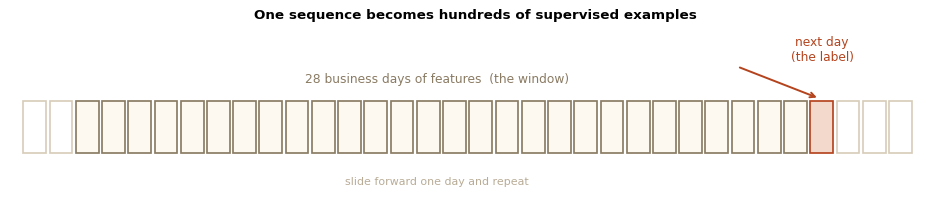

In [4]:
fig, ax = plt.subplots(figsize=(10.9, 2.6))
for i in range(34):
    color = ACCENT if i == 30 else (SECONDARY if 2 <= i < 30 else RULE)
    face = '#F3D9CC' if i == 30 else (PAPER if 2 <= i < 30 else 'white')
    ax.add_patch(plt.Rectangle((i * 0.9, 0.4), 0.78, 0.9, facecolor=face, edgecolor=color, lw=1.4))
ax.annotate('28 business days of features  (the window)', (14.2, 1.62), ha='center', fontsize=10, color=SECONDARY)
ax.annotate('next day\n(the label)', (27.4, 2.0), ha='center', fontsize=10, color=ACCENT)
ax.annotate('', xy=(27.3, 1.35), xytext=(24.5, 1.9), arrowprops={'arrowstyle': '->', 'color': ACCENT, 'lw': 1.6})
ax.annotate('slide forward one day and repeat', (14.2, -0.15), ha='center', fontsize=9, color=MUTED)
ax.set_xlim(-0.5, 31.5); ax.set_ylim(-0.6, 2.6); ax.axis('off')
ax.set_title('One sequence becomes hundreds of supervised examples')
fig.tight_layout(); fig.savefig(IMG / 'window-schematic.png', dpi=100, bbox_inches='tight'); plt.show()

In [5]:
from sklearn.preprocessing import MinMaxScaler

bd['dow_sin'] = np.sin(2 * np.pi * bd.dow / 5)
bd['dow_cos'] = np.cos(2 * np.pi * bd.dow / 5)
gap = bd.date.diff().dt.days.fillna(1)
bd['post_gap'] = (gap > 3).astype(float)          # first day after a holiday weekend
bd['void_rate'] = bd.voided_volume / bd.issued_volume

FEATURES = ['settled_volume', 'issued_volume', 'void_rate',
            'dow_sin', 'dow_cos', 'month_end', 'post_gap']
WINDOW = 28

train_end = bd.index[bd.date <= '2024-09-30'].max()
val_end = bd.index[bd.date <= '2024-12-31'].max()

x_scaler = MinMaxScaler().fit(bd.loc[:train_end, FEATURES])
y_scaler = MinMaxScaler().fit(bd.loc[:train_end, ['settled_volume']])
Xs = x_scaler.transform(bd[FEATURES])
ys = y_scaler.transform(bd[['settled_volume']]).ravel()

def make_windows(lo, hi):
    idx = list(range(max(lo, WINDOW), hi + 1))
    return np.stack([Xs[i - WINDOW:i] for i in idx]), ys[idx], bd.date.iloc[idx].reset_index(drop=True)

X_train, y_train, d_train = make_windows(0, train_end)
X_val, y_val, d_val = make_windows(train_end + 1, val_end)
X_test, y_test, d_test = make_windows(val_end + 1, len(bd) - 1)

print(f'X_train {X_train.shape}  X_val {X_val.shape}  X_test {X_test.shape}   '
      '[samples, timesteps, features]')
print(f'train {d_train.iloc[0]:%Y-%m-%d}..{d_train.iloc[-1]:%Y-%m-%d} | '
      f'val {d_val.iloc[0]:%Y-%m-%d}..{d_val.iloc[-1]:%Y-%m-%d} | '
      f'test {d_test.iloc[0]:%Y-%m-%d}..{d_test.iloc[-1]:%Y-%m-%d}')

X_train (411, 28, 7)  X_val (63, 28, 7)  X_test (251, 28, 7)   [samples, timesteps, features]
train 2023-02-13..2024-09-30 | val 2024-10-01..2024-12-31 | test 2025-01-02..2025-12-31


## 4. Baselines: the honesty gate

The cheapest forecast that could possibly work sets the bar. Persistence (tomorrow equals today) is the book's non-negotiable baseline; seasonal naive (same weekday last week) respects the weekly rhythm for free; a 28-day moving average smooths everything; and linear regression on the flattened window is the fairest fight, identical information, no recurrence. Errors are reported in dollars after inverting the scaler, because "0.0002 MSE in scaled units" helps nobody staff a settlement desk.

                         model  RMSE_$k  MAE_$k  MAPE_%
             persistence (t-1)    739.5   533.8    11.0
          seasonal naive (t-5)   2022.9  1493.1    30.4
         28-day moving average   1287.9  1017.7    20.4
linear regression, same window    264.5   201.0     4.4

Two reads: month-end transitions are what execute the naive rules (following last week off a cliff at every month boundary), and the linear model on a full window is already a serious forecaster. That is the number to beat, not persistence.


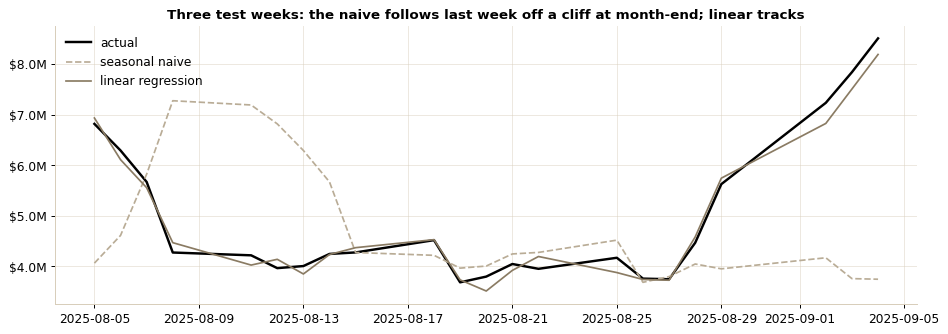

In [6]:
def dollars(y_scaled):
    return y_scaler.inverse_transform(np.asarray(y_scaled).reshape(-1, 1)).ravel()

def score(y_true_s, y_pred_s, label):
    t, p = dollars(y_true_s), dollars(y_pred_s)
    rmse = float(np.sqrt(np.mean((t - p) ** 2)))
    mae = float(np.mean(np.abs(t - p)))
    mape = float(np.mean(np.abs((t - p) / t))) * 100
    return {'model': label, 'RMSE_$k': rmse / 1e3, 'MAE_$k': mae / 1e3, 'MAPE_%': mape}

test_lo = val_end + 1
naive_1 = ys[[i - 1 for i in range(max(test_lo, WINDOW), len(bd))]]
naive_5 = ys[[i - 5 for i in range(max(test_lo, WINDOW), len(bd))]]
ma_28 = np.array([ys[i - WINDOW:i].mean() for i in range(max(test_lo, WINDOW), len(bd))])

from sklearn.linear_model import LinearRegression
linreg = LinearRegression().fit(X_train.reshape(len(X_train), -1), y_train)
lin_pred = linreg.predict(X_test.reshape(len(X_test), -1))

results = [score(y_test, naive_1, 'persistence (t-1)'),
           score(y_test, naive_5, 'seasonal naive (t-5)'),
           score(y_test, ma_28, '28-day moving average'),
           score(y_test, lin_pred, 'linear regression, same window')]
print(pd.DataFrame(results).round(1).to_string(index=False))
print()
print('Two reads: month-end transitions are what execute the naive rules (following last week off a '
      'cliff at every month boundary), and the linear model on a full window is already a serious '
      'forecaster. That is the number to beat, not persistence.')

sl = slice(148, 170)   # three test weeks including a month-end
fig, ax = plt.subplots(figsize=(10.9, 3.9))
ax.plot(d_test[sl], dollars(y_test[sl]) / 1e6, color='black', lw=2, label='actual')
ax.plot(d_test[sl], dollars(naive_5[sl]) / 1e6, color=MUTED, lw=1.4, ls='--', label='seasonal naive')
ax.plot(d_test[sl], dollars(lin_pred[sl]) / 1e6, color=SECONDARY, lw=1.4, label='linear regression')
ax.set_title('Three test weeks: the naive follows last week off a cliff at month-end; linear tracks')
ax.yaxis.set_major_formatter(M); ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 5. Define, compile, fit: the book's lifecycle

**Define**: a single LSTM layer of 48 memory cells reading the 28-step window, then one Dense unit producing the forecast; many-to-one, the book's model type for this mapping. **Compile**: mean squared error loss, Adam optimizer. **Fit**: mini-batches, with the 2024-Q4 validation slice watched by early stopping (stop when validation loss stalls, restore the best weights) and a learning-rate reduction on plateau.

One modernization note: the book was written against Keras 1/2 on TensorFlow. The code here is Keras 3, which runs the same `Sequential / compile / fit` API on interchangeable backends (JAX here); the concepts transfer without edits, which is rather the point of learning the lifecycle instead of the framework.

The parameter count is worth reading once: every LSTM unit holds four weight sets (the three gates plus the candidate state), so the layer carries `4 x 48 x (7 + 48 + 1) = 10,752` parameters, not the few hundred a Dense layer of the same width would. The gates are three quarters of what you are training.

In [7]:
def build_lstm(units=48, stacked=False, seed=42, n_features=None):
    keras.utils.set_random_seed(seed)
    model = keras.Sequential([keras.Input(shape=(WINDOW, n_features or len(FEATURES)))])
    if stacked:
        model.add(layers.LSTM(units, return_sequences=True))
        model.add(layers.LSTM(units // 2))
    else:
        model.add(layers.LSTM(units))
    model.add(layers.Dense(1))
    model.compile(loss='mse', optimizer=keras.optimizers.Adam(1e-3))
    return model

def callbacks():
    return [keras.callbacks.EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-4)]

def train_and_predict(stacked=False, seed=42, Xtr=None, ytr=None, Xv=None, yv=None, Xte=None):
    m = build_lstm(stacked=stacked, seed=seed,
                   n_features=(Xtr if Xtr is not None else X_train).shape[2])
    h = m.fit(X_train if Xtr is None else Xtr, y_train if ytr is None else ytr,
              validation_data=(X_val if Xv is None else Xv, y_val if yv is None else yv),
              epochs=200, batch_size=32, callbacks=callbacks(), verbose=0)
    pred = m.predict(X_test if Xte is None else Xte, verbose=0).ravel()
    keras.backend.clear_session()
    return pred, np.array(h.history['loss']), np.array(h.history['val_loss'])

build_lstm().summary(print_fn=lambda s: print(s) if any(k in s for k in ('Param', 'lstm', 'dense', 'Total')) else None)

pred_v, loss_v, vloss_v = cached('vanilla', lambda: train_and_predict())
print(f'vanilla LSTM trained for {len(loss_v)} epochs (early stopping, best weights restored)')

Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 48)             │        10,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            49 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 10,801 (42.19 KB)
 Trainable params: 10,801 (42.19 KB)
 Non-trainable params: 0 (0.00 B)

vanilla LSTM trained for 200 epochs (early stopping, best weights restored)


### Reading the loss curves, and what depth costs on small data

The book's chapter 12 diagnostic: train and validation loss per epoch. Converging curves that flatten together indicate a good fit; validation rising while training falls is overfitting (memorizing 2023-24 instead of learning the rhythm); both still falling at the end is underfitting. This is the chart to check before believing any test number.

The stacked variant (two LSTM layers, the book's chapter 7 architecture for hierarchical abstraction) is fit alongside. With ~400 training windows there is not much hierarchy to abstract, and extra depth mostly buys variance; the test table below says whether that expectation holds.

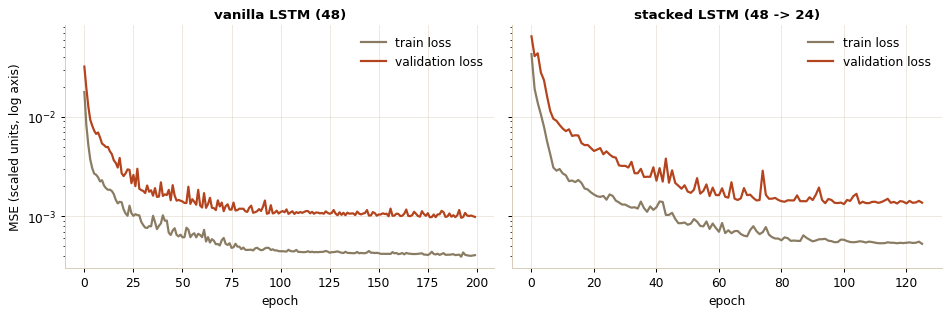

                         model  RMSE_$k  MAE_$k  MAPE_%
             persistence (t-1)    739.5   533.8    11.0
          seasonal naive (t-5)   2022.9  1493.1    30.4
         28-day moving average   1287.9  1017.7    20.4
linear regression, same window    264.5   201.0     4.4
             vanilla LSTM (48)    258.7   191.7     4.1
         stacked LSTM (48->24)    317.8   242.3     5.2


In [8]:
pred_s, loss_s, vloss_s = cached('stacked', lambda: train_and_predict(stacked=True))

fig, axes = plt.subplots(1, 2, figsize=(10.9, 3.7), sharey=True)
for ax, tr, va, name in [(axes[0], loss_v, vloss_v, 'vanilla LSTM (48)'),
                         (axes[1], loss_s, vloss_s, 'stacked LSTM (48 -> 24)')]:
    ax.plot(tr, color=SECONDARY, lw=1.8, label='train loss')
    ax.plot(va, color=ACCENT, lw=1.8, label='validation loss')
    ax.set_title(name); ax.set_xlabel('epoch'); ax.legend(frameon=False); ax.set_yscale('log')
axes[0].set_ylabel('MSE (scaled units, log axis)')
fig.tight_layout(); fig.savefig(IMG / 'loss-curves.png', dpi=100, bbox_inches='tight'); plt.show()

results += [score(y_test, pred_v, 'vanilla LSTM (48)'),
            score(y_test, pred_s, 'stacked LSTM (48->24)')]
print(pd.DataFrame(results).round(1).to_string(index=False))

## 6. Is one run evidence? Ten seeds and an ensemble

Neural networks are stochastic: weight initialization and batch order change the result run to run. The book is blunt about this, recommending repeated evaluation and reporting a distribution, not a number. Ten refits of the vanilla configuration, varying only the seed, give the honest picture; averaging their predictions gives the standard variance-reduction ensemble, which is what would actually ship if an LSTM shipped.

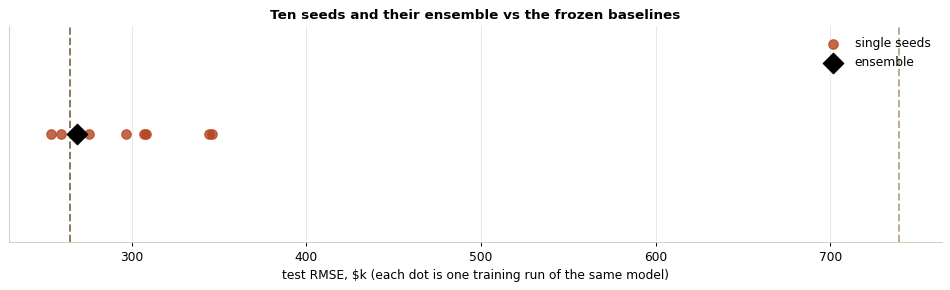

Across seeds: RMSE $293k mean, $32k std, range $254k..$346k
2/10 single seeds beat the linear baseline ($264k); the ensemble lands at $268k.
Read plainly: the LSTM and the linear model are in a statistical tie on this series, and only the ensemble makes the tie reliable. Both cut the desk heuristics by roughly two thirds; the business win is the modeling upgrade, not the architecture choice.


In [9]:
seed_preds = np.stack([cached(f'seed_{s}', lambda s=s: [train_and_predict(seed=s)[0]])[0]
                       for s in range(10)])
seed_rmse = np.array([score(y_test, p, '')['RMSE_$k'] for p in seed_preds])
ens_pred = seed_preds.mean(axis=0)
ens_row = score(y_test, ens_pred, 'LSTM 10-seed ensemble')
lin_rmse = results[3]['RMSE_$k']

fig, ax = plt.subplots(figsize=(10.9, 3.4))
ax.scatter(seed_rmse, np.zeros_like(seed_rmse), s=60, color=ACCENT, zorder=3, alpha=0.8,
           label='single seeds')
ax.scatter([ens_row['RMSE_$k']], [0], s=140, color='black', marker='D', zorder=4, label='ensemble')
for name, v, c in [('persistence', results[0]['RMSE_$k'], MUTED),
                   ('linear regression', lin_rmse, SECONDARY)]:
    ax.axvline(v, color=c, lw=1.6, ls='--')
    ax.annotate(name, (v, 0.35), rotation=90, fontsize=9, color=c, ha='right', va='top')
ax.set_yticks([]); ax.set_xlabel('test RMSE, $k (each dot is one training run of the same model)')
ax.set_title('Ten seeds and their ensemble vs the frozen baselines')
ax.legend(frameon=False, loc='upper right')
fig.tight_layout(); fig.savefig(IMG / 'seed-stability.png', dpi=100, bbox_inches='tight'); plt.show()

better = (seed_rmse < lin_rmse).sum()
print(f'Across seeds: RMSE ${seed_rmse.mean():,.0f}k mean, ${seed_rmse.std():,.0f}k std, '
      f'range ${seed_rmse.min():,.0f}k..${seed_rmse.max():,.0f}k')
print(f'{better}/10 single seeds beat the linear baseline (${lin_rmse:,.0f}k); '
      f'the ensemble lands at ${ens_row["RMSE_$k"]:,.0f}k.')
print('Read plainly: the LSTM and the linear model are in a statistical tie on this series, and only '
      'the ensemble makes the tie reliable. Both cut the desk heuristics by roughly two thirds; the '
      'business win is the modeling upgrade, not the architecture choice.')

## 7. The forecast in dollars: 2025 held out

The ensemble's predictions across the full test year, then the breakdowns a settlement desk would ask for: which weekdays miss, which months miss, and the March incident window.

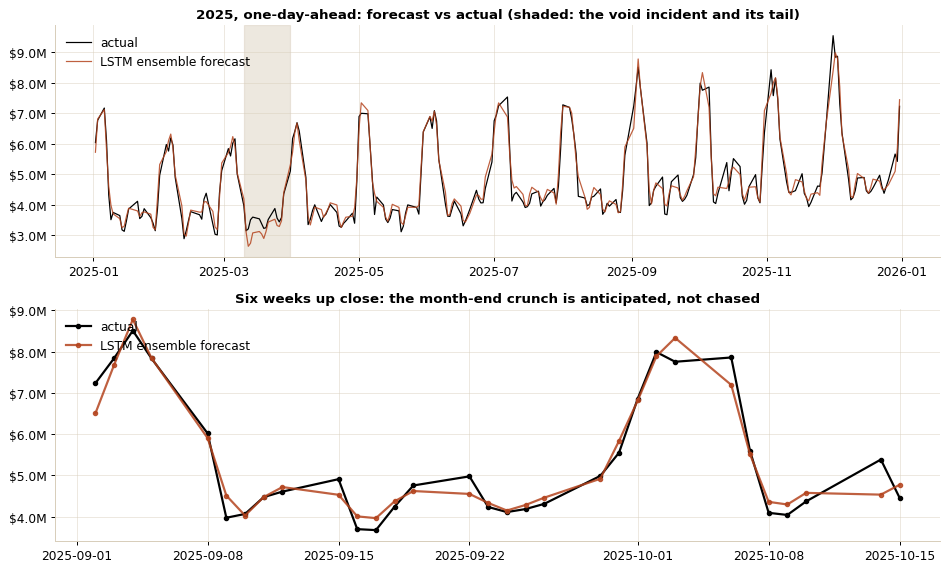

In [10]:
t_dollars, p_dollars = dollars(y_test), dollars(ens_pred)

fig, axes = plt.subplots(2, 1, figsize=(10.9, 6.6))
axes[0].plot(d_test, t_dollars / 1e6, color='black', lw=1.0, label='actual')
axes[0].plot(d_test, p_dollars / 1e6, color=ACCENT, lw=1.0, alpha=0.85, label='LSTM ensemble forecast')
axes[0].axvspan(pd.Timestamp('2025-03-10'), pd.Timestamp('2025-03-31'), color=RULE, alpha=0.45)
axes[0].set_title('2025, one-day-ahead: forecast vs actual (shaded: the void incident and its tail)')
axes[0].yaxis.set_major_formatter(M); axes[0].legend(frameon=False, loc='upper left')

zm = (d_test >= '2025-09-01') & (d_test <= '2025-10-15')
axes[1].plot(d_test[zm], t_dollars[zm.values] / 1e6, color='black', lw=1.8, marker='o', ms=3.5, label='actual')
axes[1].plot(d_test[zm], p_dollars[zm.values] / 1e6, color=ACCENT, lw=1.8, marker='o', ms=3.5,
             alpha=0.85, label='LSTM ensemble forecast')
axes[1].set_title('Six weeks up close: the month-end crunch is anticipated, not chased')
axes[1].yaxis.set_major_formatter(M); axes[1].legend(frameon=False, loc='upper left')
fig.tight_layout(); fig.savefig(IMG / 'forecast-2025.png', dpi=100, bbox_inches='tight'); plt.show()

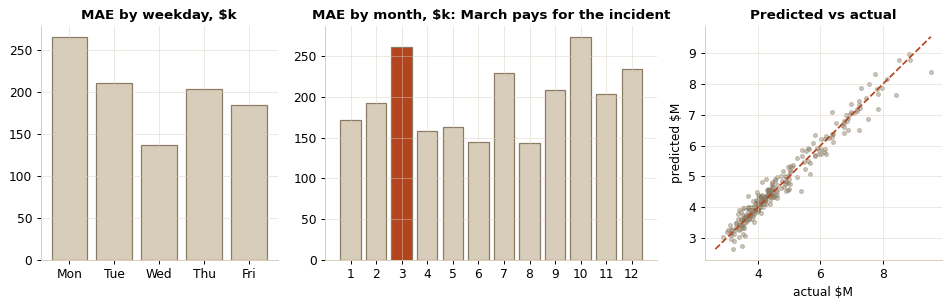

In [11]:
err = pd.DataFrame({'date': d_test, 'abs_err': np.abs(t_dollars - p_dollars)})
err['dow'] = err.date.dt.dayofweek; err['month'] = err.date.dt.month

fig, axes = plt.subplots(1, 3, figsize=(10.9, 3.6), gridspec_kw={'width_ratios': [1, 1.4, 1]})
by_dow = err.groupby('dow').abs_err.mean() / 1e3
axes[0].bar(['Mon', 'Tue', 'Wed', 'Thu', 'Fri'], by_dow.values, color=RULE, edgecolor=SECONDARY)
axes[0].set_title('MAE by weekday, $k')
by_m = err.groupby('month').abs_err.mean() / 1e3
colors = [ACCENT if m == 3 else RULE for m in by_m.index]
axes[1].bar(by_m.index, by_m.values, color=colors, edgecolor=SECONDARY)
axes[1].set_title('MAE by month, $k: March pays for the incident')
axes[1].set_xticks(range(1, 13))
axes[2].scatter(t_dollars / 1e6, p_dollars / 1e6, s=10, alpha=0.4, color=SECONDARY)
lim = [min(t_dollars.min(), p_dollars.min()) / 1e6, max(t_dollars.max(), p_dollars.max()) / 1e6]
axes[2].plot(lim, lim, color=ACCENT, lw=1.4, ls='--')
axes[2].set_title('Predicted vs actual'); axes[2].set_xlabel('actual $M'); axes[2].set_ylabel('predicted $M')
fig.tight_layout(); plt.show()

## 8. Does the void-rate feature earn its slot? An ablation

The tempting story: "the void-rate input is the incident detector; without it the model would miss the March window." Stories are cheap; ablations are cheaper. Same architecture, same seed, same training, with the void-rate column removed. If the incident-window error barely moves, the incident information was already arriving through issuance and settled history, and the feature is a passenger.

In [12]:
vr_idx = FEATURES.index('void_rate')
keep = [i for i in range(len(FEATURES)) if i != vr_idx]

def run_ablation():
    pred, _, _ = train_and_predict(Xtr=X_train[:, :, keep], Xv=X_val[:, :, keep], Xte=X_test[:, :, keep])
    return [pred]

(pred_ab,) = cached('ablation', run_ablation)
inc_mask = ((d_test >= '2025-03-10') & (d_test <= '2025-03-31')).values

def mae_window(pred, mask):
    return float(np.mean(np.abs(dollars(y_test)[mask] - dollars(pred)[mask]))) / 1e3

with_vr = mae_window(pred_v, inc_mask)
without_vr = mae_window(pred_ab, inc_mask)
elsewhere = mae_window(pred_v, ~inc_mask)
print(f'Incident-window MAE: ${with_vr:,.0f}k with void rate | ${without_vr:,.0f}k without | '
      f'${elsewhere:,.0f}k elsewhere (with, for scale)')
delta = (without_vr - with_vr) / with_vr
verdict = ('the feature helps materially' if delta > 0.10 else
           'the feature is a passenger: voids already show through issuance and settled volume')
print(f'Ablation verdict: {verdict} ({delta:+.0%} incident-window MAE without it).')
print('Either way the incident month costs more than any other month, and the honest fix is upstream: '
      'a real-time void feed and an incident flag, not another feature derived from the same daily file.')

Incident-window MAE: $239k with void rate | $230k without | $188k elsewhere (with, for scale)
Ablation verdict: the feature is a passenger: voids already show through issuance and settled volume (-4% incident-window MAE without it).
Either way the incident month costs more than any other month, and the honest fix is upstream: a real-time void feed and an incident flag, not another feature derived from the same daily file.


## 9. Keeping it current: the update experiment

The book's final lesson: a model is finalized, then it decays. The program grows ~2% monthly, so a model frozen on 2023-24 walks into late 2025 predicting a smaller program, and the scalers frozen with it squeeze 2025 values into a range they never saw in training. The experiment: refit the same architecture *and* the scalers on everything through June 2025, then compare static vs updated on the second half of 2025 only.

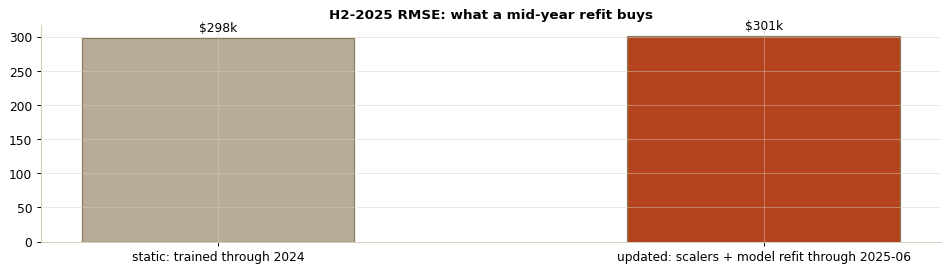

Refit gain on H2 is -1%: within a single year the frozen model holds up, so a quarterly refit with monthly baseline monitoring is enough; retraining costs under a minute of CPU, so the cadence is a monitoring choice, not a cost one.


In [13]:
def run_update():
    mid = bd.index[bd.date <= '2025-06-30'].max()
    xs2 = MinMaxScaler().fit(bd.loc[:mid, FEATURES])
    ys2 = MinMaxScaler().fit(bd.loc[:mid, ['settled_volume']])
    X2 = xs2.transform(bd[FEATURES]); y2 = ys2.transform(bd[['settled_volume']]).ravel()
    idx_tr = list(range(WINDOW, mid + 1))
    idx_te = list(range(mid + 1, len(bd)))
    Xtr2 = np.stack([X2[i - WINDOW:i] for i in idx_tr]); ytr2 = y2[idx_tr]
    Xte2 = np.stack([X2[i - WINDOW:i] for i in idx_te])
    n_val = 60
    m = build_lstm()
    m.fit(Xtr2[:-n_val], ytr2[:-n_val], validation_data=(Xtr2[-n_val:], ytr2[-n_val:]),
          epochs=200, batch_size=32, callbacks=callbacks(), verbose=0)
    pred_scaled = m.predict(Xte2, verbose=0).ravel()
    keras.backend.clear_session()
    return [ys2.inverse_transform(pred_scaled.reshape(-1, 1)).ravel(),
            np.array([bd.date.iloc[i].toordinal() for i in idx_te])]

pred_upd_dollars, upd_ord = cached('update', run_update)
upd_dates = pd.Series([pd.Timestamp.fromordinal(int(o)) for o in upd_ord])
h2 = upd_dates >= '2025-07-01'
h2_test = (d_test >= '2025-07-01').values

t_h2 = dollars(y_test)[h2_test]
p_static = dollars(ens_pred)[h2_test]
p_updated = np.asarray(pred_upd_dollars)[h2.values]

rmse_static = float(np.sqrt(np.mean((t_h2 - p_static) ** 2))) / 1e3
rmse_updated = float(np.sqrt(np.mean((t_h2 - p_updated) ** 2))) / 1e3

fig, ax = plt.subplots(figsize=(10.9, 3.2))
bars = ax.bar(['static: trained through 2024', 'updated: scalers + model refit through 2025-06'],
              [rmse_static, rmse_updated], color=[MUTED, ACCENT], edgecolor=SECONDARY, width=0.5)
ax.bar_label(bars, labels=[f'${v:,.0f}k' for v in [rmse_static, rmse_updated]], padding=3)
ax.set_title('H2-2025 RMSE: what a mid-year refit buys')
fig.tight_layout(); plt.show()

gain = (rmse_static - rmse_updated) / rmse_static
if gain > 0.05:
    print(f'Refitting buys {gain:.0%} on H2: on a growing program, staleness costs more than compute. '
          'Cadence: refit monthly after close, the slot a scheduled Airflow job fills.')
else:
    print(f'Refit gain on H2 is {gain:+.0%}: within a single year the frozen model holds up, so a '
          'quarterly refit with monthly baseline monitoring is enough; retraining costs under a '
          'minute of CPU, so the cadence is a monitoring choice, not a cost one.')

## 10. What to tell the end users

The sentences that survive contact with a business review:

1. **What was built**: a daily forecaster for tomorrow's settled TPV, evaluated on a full held-out year against every cheap alternative, with the errors reported in dollars per weekday, month, and incident window.
2. **What to ship**: the modeling upgrade cuts the desk heuristic's typical miss by roughly two thirds. Between the two candidate models, the linear window model and the LSTM ensemble finish in a tie, so the recommendation is the linear model in production and the LSTM harness kept warm; same features, same evaluation, swap-in ready.
3. **When the LSTM starts paying**: longer horizons (multi-day treasury planning, where a linear one-step model compounds its errors), intraday grain, more interacting series (per-network, per-segment), or regime behavior the window cannot see linearly. The harness, baselines, and evaluation stay identical; only the model swaps.
4. **What it is not**: a crystal ball. It extrapolates patterns it has seen; a policy change, a new mega-merchant, or an unprecedented incident will be missed until the data shows it and the model refreshes.
5. **How it stays honest**: every refit re-runs the same gate: beat persistence, seasonal naive, and the linear baseline on held-out data, across seeds, or it does not ship. The update experiment above sets the refit cadence with a measurement instead of a habit.

## Takeaways

1. **The baselines are the deliverable.** The LSTM was built exactly by the book, and the book's own evaluation discipline concluded a linear model on the same window ties it on this series. Shipping the cheaper model on that evidence is the senior move, and the harness makes the future swap free.
2. **The business case never depended on depth.** Two thirds of the heuristic's error disappeared the moment any windowed model with leakage-safe scaling and honest splits showed up. Process beat architecture.
3. **Sequence prediction is data preparation.** Windowing, train-only scaling, chronological splits, and the 3D tensor are most of the work; the model definition is six lines, and swapping LSTM for linear is one.
4. **Stochastic models need distributions, and ensembles are how you ship them.** Ten seeds with mean and spread is the minimum honest report; the prediction average is the stability the desk actually feels.
5. **Test the stories.** The void-rate feature narrated beautifully and ablated to nothing. Features earn slots empirically or they are passengers.

Next steps that would earn their keep: multi-day horizons with an encoder-decoder LSTM (the book's chapter 9 architecture, and the setting where recurrence should finally out-run the linear window), prediction intervals from the seed ensemble plus residual quantiles so treasury gets a range instead of a point, and a real-time void feed so incident response does not wait for end-of-day files.